In [50]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [51]:
prices_1_raw = pd.read_csv("../datasets/tutorial/prices_round_0_day_-1.csv")
prices_2_raw = pd.read_csv("../datasets/tutorial/prices_round_0_day_-2.csv")

In [52]:
prices_1_raw.columns[0].split(';')

['day',
 'timestamp',
 'product',
 'bid_price_1',
 'bid_volume_1',
 'bid_price_2',
 'bid_volume_2',
 'bid_price_3',
 'bid_volume_3',
 'ask_price_1',
 'ask_volume_1',
 'ask_price_2',
 'ask_volume_2',
 'ask_price_3',
 'ask_volume_3',
 'mid_price',
 'profit_and_loss']

In [53]:
prices_1_raw.values[:, 0].shape

(20000,)

In [54]:
cols = prices_1_raw.columns[0].split(";")
day_1_values = np.array([i.split(";") for i in prices_1_raw.values[:, 0]]).T

In [55]:
day_1_values

array([['-1', '-1', '-1', ..., '-1', '-1', '-1'],
       ['0', '0', '100', ..., '999800', '999900', '999900'],
       ['TOMATOES', 'EMERALDS', 'EMERALDS', ..., 'TOMATOES', 'TOMATOES',
        'EMERALDS'],
       ...,
       ['', '', '', ..., '', '', ''],
       ['5006.0', '10000.0', '10000.0', ..., '4957.5', '4957.0',
        '10000.0'],
       ['0.0', '0.0', '0.0', ..., '0.0', '0.0', '0.0']], dtype='<U8')

In [56]:
len(cols), day_1_values.shape

(17, (17, 20000))

In [57]:
prices_1 = pd.DataFrame(
    {
        cols[i]: day_1_values[i] for i in range(len(cols))
    }
)

In [58]:
cols_day_2 = prices_2_raw.columns[0].split(";")
cols == cols_day_2

True

In [59]:
day_2_values = np.array([i.split(";") for i in prices_2_raw.values[:, 0]]).T

In [60]:
prices_2 = pd.DataFrame(
    {
        cols[i]: day_2_values[i] for i in range(len(cols))
    }
)

In [70]:
prices_1.shape[0] == prices_2.shape[0], len(prices_1), len(prices_2)

(True, 20000, 20000)

In [149]:
tutorial_prices = pd.concat([prices_2, prices_1], axis=0)
len(tutorial_prices) == len(prices_1) + len(prices_2)

True

In [74]:
tutorial_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,,,10008,11,10010,25,,,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,,,5007,7,5008,17,,,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992,16,5007,7,5008,16,,,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,,,10008,15,10010,20,,,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,,,5008,6,5009,20,,,5001.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1,999700,EMERALDS,9992,12,9990,26,,,10008,12,10010,26,,,10000.0,0.0
19996,-1,999800,EMERALDS,9992,13,9990,20,,,10008,13,10010,20,,,10000.0,0.0
19997,-1,999800,TOMATOES,4951,6,4949,18,,,4964,6,4965,18,,,4957.5,0.0
19998,-1,999900,TOMATOES,4950,10,4949,25,,,4964,10,4965,25,,,4957.0,0.0


In [75]:
trades_day_1_raw = pd.read_csv("../datasets/tutorial/trades_round_0_day_-1.csv")
trades_day_2_raw = pd.read_csv("../datasets/tutorial/trades_round_0_day_-2.csv")

In [77]:
import re

In [111]:
trade_cols = trades_day_1_raw.columns[0].split(";")
(trade_cols == trades_day_2_raw.columns[0].split(";"))

True

In [121]:
trade_values = np.array([i.split(";")for i in  trades_day_1_raw.values[:, 0]]).T
trade_values_2 = np.array([i.split(";")for i in  trades_day_2_raw.values[:, 0]]).T

In [114]:
trade_values.shape, len(trade_cols)

((7, 631), 7)

In [120]:
trade_cols

['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity']

In [122]:
trade_day_1 = pd.DataFrame(
    {
        trade_cols[i]: trade_values[i] for i in range(len(trade_cols))
    }
)
trade_day_2 = pd.DataFrame(
    {
        trade_cols[i]: trade_values_2[i] for i in range(len(trade_cols))
    }
)

In [148]:
all_trades = pd.concat([trade_day_2, trade_day_1], axis=0)
len(all_trades) == len(trade_day_1) + len(trade_day_2)

True

In [147]:
pd.concat([trade_day_2, trade_day_1], axis=0).index

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            621, 622, 623, 624, 625, 626, 627, 628, 629, 630],
           dtype='int64', length=1219)

In [150]:
tutorial_prices.to_csv("../datasets/tutorial/tutorial_prices", index_label=False)
all_trades.to_csv("../datasets/tutorial/tutorial_trades", index_label=True)

In [151]:
tutorial_prices = pd.read_csv("../datasets/tutorial/tutorial_prices")
all_trades = pd.read_csv("../datasets/tutorial/tutorial_trades")

In [152]:
tutorial_prices.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')

In [157]:
tutorial_prices['product'].unique()
emerald_mask = (tutorial_prices['product'] == "EMERALDS")
tomato_mask = ([not e for e in emerald_mask])

In [162]:
tutorial_prices[tomato_mask]['mid_price']

1        5000.0
2        5002.5
4        5001.0
7        5001.5
9        5001.5
          ...  
19990    4959.0
19993    4959.0
19994    4956.5
19997    4957.5
19998    4957.0
Name: mid_price, Length: 20000, dtype: float64

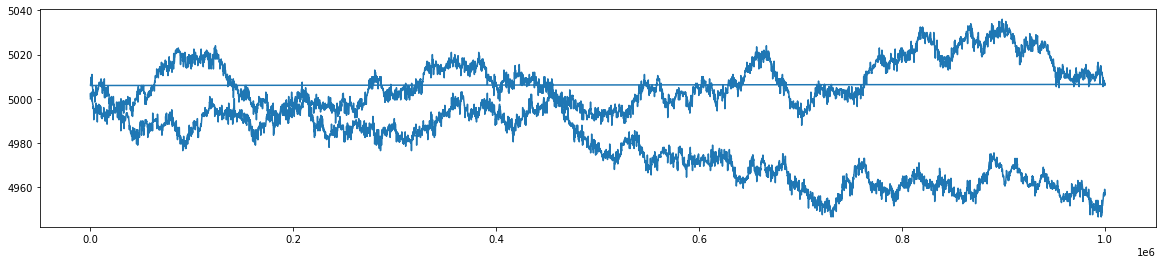

In [183]:
plt.figure(figsize=(20, 4))

plt.plot(tutorial_prices[tomato_mask]['timestamp'], tutorial_prices[tomato_mask]['mid_price'])

In [181]:
tutorial_prices[emerald_mask]['mid_price'].mean()

9999.9976

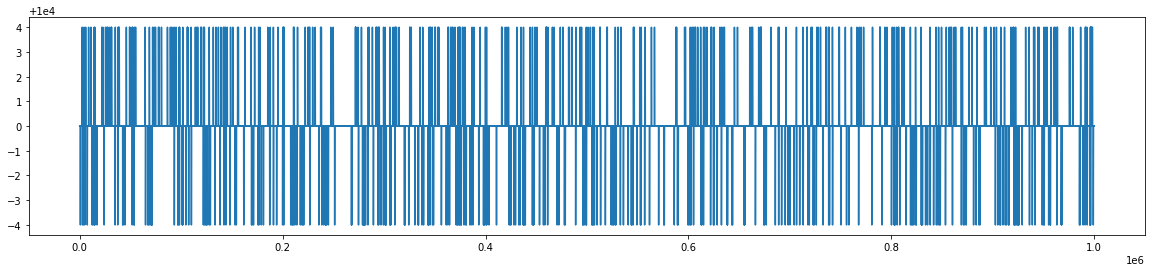

In [196]:
plt.figure(figsize=(20, 4))
plt.plot(tutorial_prices[emerald_mask]['timestamp'], tutorial_prices[emerald_mask]['mid_price'], 
)

In [186]:
len(tutorial_prices[emerald_mask]), len(tutorial_prices[tomato_mask])

(20000, 20000)

In [193]:
spread = tutorial_prices[emerald_mask]['mid_price'] - tutorial_prices[tomato_mask]['mid_price']

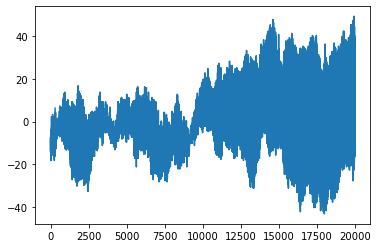

In [197]:
plt.plot(spread.index, spread - spread.mean())

### roughly, try mean reversion day 1 and momentum day 2